<a href="https://colab.research.google.com/github/DeepanshuSharma1607/project/blob/main/diffusion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U diffusers

## Local Inference on GPU
Model page: https://huggingface.co/black-forest-labs/FLUX.2-klein-base-9b-fp8

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/black-forest-labs/FLUX.2-klein-base-9b-fp8)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

The model you are trying to use is gated. Please make sure you have access to it by visiting the model page.To run inference, either set HF_TOKEN in your environment variables/ Secrets or run the following cell to login. 🤗

In [2]:
!pip install -U diffusers transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 80.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.17.0
    Uninstalling transformers-5.17.0:
      Successfully uninstalled transformers-5.17.0


In [3]:
import torch
from diffusers import StableDiffusionXLPipeline

# 1. Load an open, unrestricted SDXL model (Fixed typo: 1-0 instead of 1.0)
pipe = StableDiffusionXLPipeline.from_pretrained(
    "Lykon/dreamshaper-xl-1-0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to("cuda")

# 2. Define your prompt (unrestricted)

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['subtle wisps of dry ice smoke trace along the floor tires . shot from a straight - on , low - profile front angle . extreme detail on the metallic paint flakes , chrome grilles , and brake calipers . commercial luxury automotive advertising style , hasselblad medium format look , hyper - clean composition , sophisticated lighting , moody and elegant .']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['subtle wisps of dry ice smoke trace along the floor tires . shot from a straight - on , low - profile front angle . extreme detail on the metallic paint flakes , chrome grilles , and brake calipers . commercial luxury automotive advertising style , hasselblad medium format look , hyper - clean composition , sophisticated lighting , moody and elegant .']


  0%|          | 0/45 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


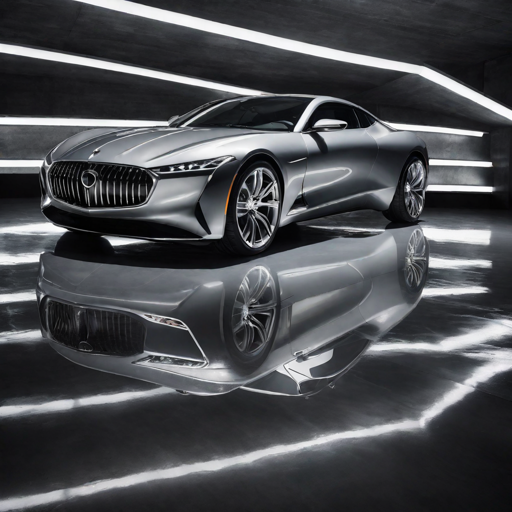

In [14]:
prompt = "A minimal and dramatic studio commercial photograph of a pristine, metallic silver luxury sports coupe. The car is centered on a seamless, highly reflective dark polished concrete floor inside a pitch-black infinity studio. A singular, long, continuous overhead softbox light strip runs perfectly down the spine of the vehicle, casting a razor-sharp, elegant highlight along the side profiles and body lines. Subtle wisps of dry ice smoke trace along the floor tires. Shot from a straight-on, low-profile front angle. Extreme detail on the metallic paint flakes, chrome grilles, and brake calipers. Commercial luxury automotive advertising style, Hasselblad medium format look, hyper-clean composition, sophisticated lighting, moody and elegant."
negative_prompt = "ugly, blurry, deformed, poorly drawn, low resolution"

# 1. Generate full-resolution image (1024x1024)
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=45,
    guidance_scale=7.5
).images[0]

# 3. Display a resized 512x512 preview that fits your screen cleanly
display(image.resize((512, 512)))